[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# 📝 Ejercicio Guiado — Predicción de Precios de Teléfonos Móviles con Ensambles

**Nombre:** Jeronimo Campuzano, Laura Andrea Castrillon Fajardo, Samuel Llano
**Fecha:** 25 de Agosto de 2026

---

En este ejercicio construirás modelos de **Random Forest Regressor** y **Gradient Boosting Regressor** para predecir el precio (en USD) de teléfonos móviles a partir de sus especificaciones técnicas.

El dataset proviene de Kaggle:
📦 [Mobile Phone Price Dataset](https://www.kaggle.com/datasets/rkiattisak/mobile-phone-price)

Seguirás una estructura parecida al notebook de referencia de clasificación (**Penguins RF & GB**) para construir tus `Pipeline` y `ColumnTransformer`, pero adaptada a un problema de **regresión** con un dataset bastante más "sucio":

| Aspecto | Penguins RF & GB (referencia) | **Este ejercicio** |
|---|---|---|
| Tarea | Clasificación | **Regresión** |
| División | Train / Test | **Train / Validation / Test** |
| Preprocesamiento numérico | `StandardScaler` | `StandardScaler` (dentro de un `Pipeline` con imputación) |
| Preprocesamiento categórico | `OneHotEncoder` | `OneHotEncoder` (dentro de un `Pipeline` con imputación) |
| Limpieza de datos | Mínima (eliminar nulos) | **Importante** — columnas numéricas guardadas como texto, formatos irregulares |
| Búsqueda de hiperparámetros | `GridSearchCV` | `GridSearchCV` (con métrica de regresión) |
| Evaluación | Accuracy, F1, matriz de confusión | **R², MAE (con interpretación obligatoria)** |
| Predicción final | — | **Muestra sintética propia** |

### ⚠️ Los retos de este dataset

A diferencia de Penguins (donde las columnas ya venían limpias), aquí vas a tener que **tomar decisiones de preprocesamiento por tu cuenta**. Dos columnas en particular te van a dar trabajo:

- **`Camera (MP)`**: no es un número simple. Puede tener uno o varios valores (múltiples lentes) y a veces texto que no es una resolución.
- **`Price ($)`** (¡tu variable objetivo!): viene mezclada con símbolos de moneda, separadores de miles y espacios.

No te vamos a dar la línea de código exacta para limpiarlas — te daremos pistas y preguntas guía. **Tú decides qué camino seguir.**

### Columnas del dataset

| Columna | Tipo | Descripción |
|---|---|---|
| `Brand` | Categórica | Marca del fabricante (Apple, Samsung, Xiaomi...) |
| `Model` | Categórica ⚠️ alta cardinalidad | Modelo específico — casi todos los valores son únicos |
| `Storage` | Numérica/Texto | Almacenamiento interno (ej. `"128 GB"`) |
| `RAM` | Numérica/Texto | Memoria RAM (ej. `"6 GB"`) |
| `Screen Size (inches)` | Numérica | Tamaño de pantalla en pulgadas |
| `Camera (MP)` | Texto ⚠️ **reto** | Especificación de cámara(s), formato irregular (ej. `"48 + 8 + 2 + 2"`) |
| `Battery Capacity (mAh)` | Numérica | Capacidad de batería |
| `Price ($)` 🎯 ⚠️ **reto** | Numérica/Texto | **Variable objetivo** — precio en USD, formato irregular |

> 💡 Los nombres exactos de columnas (espacios extra, mayúsculas) pueden variar levemente según la versión del CSV que descargues. Verifica siempre con `df.columns.tolist()` antes de escribir código que dependa de un nombre exacto.

## 0. Descarga del dataset

**Opción A – Kaggle API:**
```bash
!pip install kaggle -q
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rkiattisak/mobile-phone-price --unzip
```

**Opción B – Descarga manual:**
Descarga el archivo `.csv` desde Kaggle y súbelo a la misma carpeta del notebook.

> ⚠️ Revisa el nombre exacto del archivo descargado (puede ser algo como `Mobile phone price.csv`) y ajústalo en el `pd.read_csv(...)` de la siguiente sección.

## 1. Librerías

Importa todas las librerías que necesitarás durante el ejercicio.

**Pistas — qué importar y de dónde:**
- `pandas`, `numpy`, `re` (expresiones regulares) y `matplotlib.pyplot`
- De `sklearn.ensemble`: `RandomForestRegressor` y `GradientBoostingRegressor`
- De `sklearn.model_selection`: `train_test_split` y `GridSearchCV`
- De `sklearn.pipeline`: `Pipeline`
- De `sklearn.compose`: `ColumnTransformer`
- De `sklearn.preprocessing`: `StandardScaler`, `OneHotEncoder`
- De `sklearn.impute`: `SimpleImputer`
- De `sklearn.metrics`: `mean_absolute_error`, `mean_squared_error`, `r2_score`
- Define `random_state = 42` para reproducibilidad

> 💡 **¿Por qué `re` (regex)?**
> Vas a necesitar extraer números de texto irregular (por ejemplo, sacar `128` de `"128 GB"`, o los distintos valores de MP de `"48 + 8 + 2 + 2"`). Las expresiones regulares son la herramienta ideal para esto. Si no las conoces, la función `re.findall(r'\d+\.?\d*', texto)` te devuelve una lista con todos los números que aparecen en un string — puede servirte como punto de partida.

In [46]:
# Importaciones necesarias:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures,
    FunctionTransformer,
)

# Seed para reproductibilidad
random_state = 42

## 2. Carga y limpieza de datos

Carga el dataset y realiza las transformaciones necesarias para poder usarlo. Esta es la sección más importante del ejercicio — tómate tu tiempo.

**Pistas generales:**
- Usa `pd.read_csv('nombre_del_archivo.csv')` para cargar
- Revisa `.shape`, `.head()`, `.info()` e `.isnull().sum()`
- Verifica los nombres de columnas con `df.columns.tolist()`. Si encuentras espacios extra al inicio o final de los nombres, límpialos con `df.columns = df.columns.str.strip()`

### 2a. `Storage` y `RAM`
Estas columnas vienen como texto (ej. `"128 GB"`, `"6 GB"`). Necesitas quedarte solo con el número y convertirlo a tipo numérico.
- Revisa los valores únicos con `.unique()` antes de limpiar, para confirmar el patrón exacto (¿siempre dice "GB"? ¿hay espacios inconsistentes?)
- Una combinación de `.str.extract()` o `.str.replace()` con expresiones regulares, seguida de `.astype(int)`, debería funcionar

### 2b. `Camera (MP)` — ⚠️ reto
Esta columna **no es un solo número**. Antes de programar nada, explora:
```python
df['Camera (MP)'].sample(15)
```
Vas a notar que:
- Puede haber **uno o varios valores separados por `+`** (varios lentes: cámara principal, ultra gran angular, macro, profundidad...)
- Algunos de esos valores **no son una resolución en MP** (por ejemplo, sensores marcados como `"3D"` o `"ToF"` que no tienen megapíxeles)

**Preguntas para guiar tu decisión:**
- ¿Qué información resumen quieres extraer de esta columna? Algunas opciones válidas: número de cámaras (lentes), suma total de MP, el valor máximo de MP (cámara principal), el promedio.
- ¿Puedes crear más de una columna nueva a partir de esta? (por ejemplo `n_camaras` y `camera_mp_total`)
- ¿Cómo vas a manejar los tokens que no son números (`"3D"`, `"ToF"`)? Si los ignoras, ¿pierdes información importante o es razonable descartarlos?

No hay una única respuesta correcta — documenta con un comentario **por qué** elegiste tu estrategia.

### 2c. `Price ($)` — ⚠️ reto (¡es tu variable objetivo!)
Explora los valores únicos o una muestra:
```python
df['Price ($)'].sample(15)
```
Es muy probable que encuentres una mezcla de formatos: algunos precios con el símbolo `$`, otros sin él, algunos con comas como separador de miles (ej. `"$1,199"`), y posiblemente espacios en blanco sobrantes.

**Preguntas para guiar tu decisión:**
- ¿Qué caracteres necesitas eliminar antes de poder convertir la columna a numérica?
- Si intentas `pd.to_numeric(df['Price ($)'])` directamente sin limpiar, ¿qué error obtienes? ¿Qué te dice ese error sobre los datos?
- Después de limpiar, verifica que no haya quedado ningún valor nulo o mal convertido en tu variable objetivo — un solo precio corrupto puede arruinar el entrenamiento.
- Considera renombrar la columna limpia a algo más simple como `Price` para que sea más fácil de referenciar en el resto del notebook.

### 2d. `Model` — decisión de diseño
Revisa cuántos valores únicos tiene esta columna con `.nunique()` y compáralo con el número total de filas.
- ¿Tiene sentido usar esta columna como feature categórica? Piensa en qué pasaría si aplicaras `OneHotEncoder` sobre una columna donde casi todos los valores son únicos — ¿el modelo podría generalizar a modelos de teléfono que nunca vio en entrenamiento?
- Decide si la vas a **descartar** o si vas a intentar extraer algo útil de ella (por ejemplo, si el nombre del modelo contiene palabras como "Pro", "Max", "Lite"). Justifica tu decisión con un comentario.

In [47]:
# Carga el dataset:
mobiles = pd.read_csv("data/Mobile phone price.csv")

# Algunas columnas traen espacios extra en el nombre (ej. "Storage ", "RAM ") que no se ven al imprimir:
mobiles.columns = mobiles.columns.str.strip()

In [48]:
mobiles.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Camera (MP),Battery Capacity (mAh),Price ($)
0,Apple,iPhone 13 Pro,128 GB,6 GB,6.1,12 + 12 + 12,3095,999
1,Samsung,Galaxy S21 Ultra,256 GB,12 GB,6.8,108 + 10 + 10 + 12,5000,1199
2,OnePlus,9 Pro,128 GB,8 GB,6.7,48 + 50 + 8 + 2,4500,899
3,Xiaomi,Redmi Note 10 Pro,128 GB,6 GB,6.67,64 + 8 + 5 + 2,5020,279
4,Google,Pixel 6,128 GB,8 GB,6.4,50 + 12.2,4614,799


In [49]:
# Tipos de datos y valores nulos:
mobiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand                   407 non-null    str  
 1   Model                   407 non-null    str  
 2   Storage                 407 non-null    str  
 3   RAM                     407 non-null    str  
 4   Screen Size (inches)    407 non-null    str  
 5   Camera (MP)             407 non-null    str  
 6   Battery Capacity (mAh)  407 non-null    int64
 7   Price ($)               407 non-null    str  
dtypes: int64(1), str(7)
memory usage: 25.6 KB


In [50]:
# Dimensiones del dataset:
mobiles.shape

(407, 8)

In [51]:
# Identifica los valores únicos de la columna RAM:
mobiles['Storage'].value_counts()

Storage
128GB     125
128        74
128 GB     51
64GB       49
32GB       27
256        23
64         18
64 GB      16
256GB      10
256 GB      7
32 GB       3
512         3
32          1
Name: count, dtype: int64

In [52]:
# Identifica los valores únicos de la columna RAM:
mobiles['RAM'].value_counts()

RAM
4GB      68
6GB      59
8GB      42
4        35
8        34
6        28
4 GB     25
3GB      22
6 GB     20
8 GB     19
12       11
12GB      9
2GB       9
3         9
3 GB      7
12 GB     5
5GB       2
2 GB      1
16        1
2         1
Name: count, dtype: int64

In [53]:
# Limpia las columnas Storage y RAM (elimina el sufijo textual y convierte a numérico):
mobiles['Storage'] = mobiles['Storage'].str.extract(r'(\d+)').astype(int)
mobiles['RAM'] = mobiles['RAM'].str.extract(r'(\d+)').astype(int)


In [54]:
mobiles['Storage'].value_counts()

Storage
128    250
64      83
256     40
32      31
512      3
Name: count, dtype: int64

In [55]:
mobiles['RAM'].value_counts()

RAM
4     128
6     107
8      95
3      38
12     25
2      11
5       2
16      1
Name: count, dtype: int64

En ambas columnas existian valores de tipo 'object' que incluian números, espacios y letras, lo que generaba para Storage 13 valores diferentes y para RAM 20, luego de hacer el parseo donde nos quedamos unicamente con 5 y 8 para Storage y RAM respectivamente

In [56]:
# 2b. Limpia / transforma la columna Camera (MP).
mobiles['Camera (MP)'].value_counts()

Camera (MP)
13MP + 2MP + 2MP          29
48MP + 8MP + 2MP + 2MP    16
48+8+2+2                  13
64MP + 8MP + 2MP          11
13MP + 2MP                11
                          ..
48+8+5+5                   1
64+12+12                   1
108+48+12+0.3              1
48+16+2                    1
48+13+8+2                  1
Name: count, Length: 143, dtype: int64

In [57]:
def parse_camera(texto):
    values = []
    for camera_description in texto.split('+'):
        parte = camera_description.strip().replace('MP', '').strip()
        try:
            values.append(float(parte))
        except ValueError:
            continue  
    return values

In [58]:
cameras = mobiles['Camera (MP)'].apply(parse_camera)

mobiles['Camera Avg'] = cameras.apply(lambda v: sum(v) / len(v))
mobiles['Camera Max'] = cameras.apply(max)
mobiles['Camera Count'] = cameras.apply(len)

# Explora primero los valores únicos, luego decide tu estrategia (ver pistas arriba).
# Documenta tu decisión con un comentario antes de tu código:

In [59]:
mobiles.drop(columns=['Camera (MP)'], inplace=True)

In [60]:
mobiles.head()

,Brand,Model,Storage,RAM,Screen Size (inches),Battery Capacity (mAh),Price ($),Camera Avg,Camera Max,Camera Count
0,Apple,iPhone 13 Pro,128,6,6.1,3095,999,12.00,12.0,3
1,Samsung,Galaxy S21 Ultra,256,12,6.8,5000,1199,35.00,108.0,4
2,OnePlus,9 Pro,128,8,6.7,4500,899,27.00,50.0,4
3,Xiaomi,Redmi Note 10 Pro,128,6,6.67,5020,279,19.75,64.0,4
4,Google,Pixel 6,128,8,6.4,4614,799,31.10,50.0,2


Camera MPA tenia valores de tipo 'object', los cuales incluian numeros, signos especiales y letras, esto no nos da una representación util, de momento se hace una estandarización bajo 3 aspectos, promedio de la especificacion de la camara, el valor max y la cantidad de camaras; esto parte de una hipotesis de identificar cual puede tener mayor codependencia, lo cual se revisará en el analisis exploratorio. 

In [61]:
# 2c. Limpia la columna Price ($) y conviértela a numérica.
mobiles['Price ($)']

0       999
1      1199
2       899
3       279
4       799
       ... 
402    1049
403     349
404    1099
405     429
406     649
Name: Price ($), Length: 407, dtype: str

In [62]:
# Revisar cuantas columnas tienen presencia de "$" en la columna Price ($)
mobiles['Price ($)'].str.contains('$', regex=False).sum()

np.int64(210)

In [63]:
mobiles['Price ($)'] = mobiles['Price ($)'].str.replace('$', '').str.replace(',', '').astype(int)

In [64]:
mobiles['Price ($)']

0       999
1      1199
2       899
3       279
4       799
       ... 
402    1049
403     349
404    1099
405     429
406     649
Name: Price ($), Length: 407, dtype: int64

Price era definido como un 'objet' puesto que habian 210 columnas que tenian $ en el registro, entonces debemos de quitarlo y convertirlo a int ya que no cuenta con valores decimales

In [65]:
# 2d. Decide qué hacer con la columna Model (descartarla o transformarla) y justifica con un comentario:
mobiles['Model'].value_counts()

Model
Poco X3 Pro          6
Redmi 10 Prime       5
Y33s                 5
iPhone XR            5
C21Y                 5
                    ..
Moto G Pro           1
P30 Lite             1
Mi 10 Lite 5G        1
iPhone 12 Pro Max    1
Reno3                1
Name: count, Length: 239, dtype: int64

In [66]:
mobiles = mobiles.drop(columns=['Model'])

Model tiene 239 valores únicos en 407 filas, demasiada cardinalidad para OneHotEncoder, la mayoría de los modelos son casi únicos y no generalizan a val/test. Brand ya captura la señal del fabricante, así que descartamos Model.

In [67]:
mobiles = mobiles[~mobiles['Brand'].isin(['Sony', 'CAT'])]

mobiles['Brand'].value_counts()

Brand
Samsung       79
Xiaomi        67
Oppo          56
Realme        43
Vivo          35
Apple         30
Nokia         28
Motorola      23
OnePlus       15
Huawei        12
Google         7
Asus           4
LG             3
Blackberry     3
Name: count, dtype: int64

Sony y CAT solo tienen 1 teléfono cada uno en el dataset, muy pocos datos para que el modelo aprenda algo útil de esas categorías, las descartamos:

In [68]:
mobiles['Screen Size (inches)'] = mobiles['Screen Size (inches)'].str.extract(r'(\d+\.?\d*)').astype(float)

Screen era de tipo 'object' a pesar de ser numeros con uno o dos decimales, por eso se decide cambiar a float

In [69]:
# Verifica que todos los tipos de dato sean correctos después de la limpieza (.dtypes):
mobiles.dtypes

Brand                         str
Storage                     int64
RAM                         int64
Screen Size (inches)      float64
Battery Capacity (mAh)      int64
Price ($)                   int64
Camera Avg                float64
Camera Max                float64
Camera Count                int64
dtype: object

## 3. Análisis Exploratorio (EDA)

Antes de modelar, es fundamental entender los datos. Realiza los siguientes análisis y escribe una interpretación debajo de cada gráfica.

### 3a. Distribución del target (`Price`)
**Pistas:**
- Crea un histograma con `plt.hist(df['Price'], bins=40, ...)`
- ¿La distribución es simétrica o tiene sesgo? ¿Hay outliers evidentes (teléfonos ultra premium)?
- Calcula también la media, mediana y desviación estándar del precio

### 3b. Correlación de variables numéricas con el target
**Pistas:**
- Selecciona solo las columnas numéricas con `.select_dtypes(include='number')` (deben incluir tus columnas nuevas derivadas de `Camera (MP)`)
- Calcula la correlación con `.corr()['Price'].drop('Price').sort_values()`
- Grafica las correlaciones como barras horizontales
- ¿Qué variables numéricas están más correlacionadas con el precio? ¿Tus features de cámara aportan señal?

### 3c. Boxplots de variables categóricas / discretas clave
**Pistas:**
- Crea boxplots de `Price` agrupados por `Brand`
- Crea también un boxplot de `Price` agrupado por `RAM` (una vez numérica, ordénala antes de graficar)
- Usa `df.boxplot(column='Price', by='Brand', ...)` o matplotlib manual
- ¿Qué marca tiene precios más altos? ¿La relación con RAM es la que esperarías?

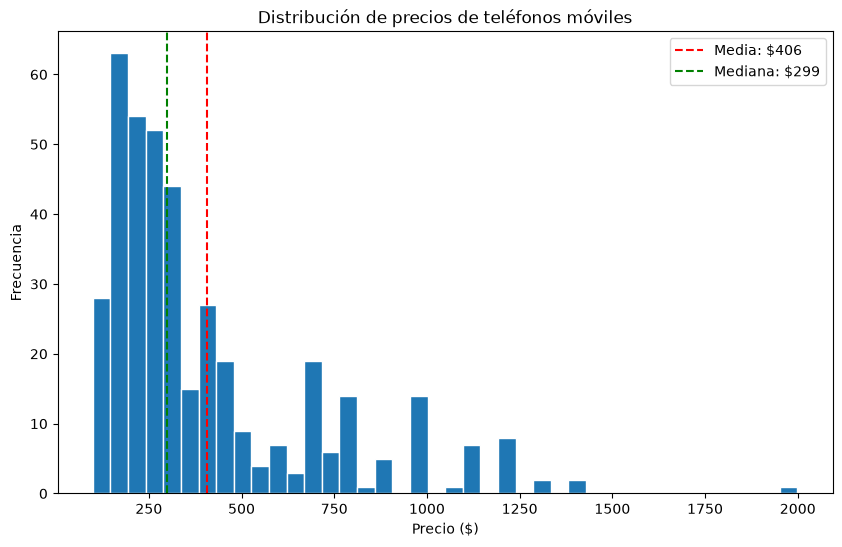

Media: $406.39
Mediana: $299.00
Desviación estándar: $297.08


In [70]:
# 3a. Histograma del target (Price):
# Pista: usa plt.hist(..., bins=40, edgecolor='white')
# Agrega líneas verticales para la media (roja) y la mediana (verde)
# Pista: plt.axvline(df['Price'].mean(), color='red', linestyle='--', label='Media')
plt.figure(figsize=(10, 6))
plt.hist(mobiles['Price ($)'], bins=40, edgecolor='white')

media = mobiles['Price ($)'].mean()
mediana = mobiles['Price ($)'].median()

plt.axvline(media, color='red', linestyle='--', label=f'Media: ${media:.0f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: ${mediana:.0f}')

plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.title('Distribución de precios de teléfonos móviles')
plt.legend()
plt.show()

print(f"Media: ${media:.2f}")
print(f"Mediana: ${mediana:.2f}")
print(f"Desviación estándar: ${mobiles['Price ($)'].std():.2f}")




**📝 Interpretación del histograma:**
La distribución tiene una media>mediana lo cual hace que tenga un sesgo hacia la derecha, la media es más representativa que la mediana.

In [71]:
Q1 = mobiles['Price ($)'].quantile(0.25)
Q3 = mobiles['Price ($)'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"Límite inferior: ${limite_inferior:.2f}")
print(f"Límite superior: ${limite_superior:.2f}")

outliers = mobiles[(mobiles['Price ($)'] < limite_inferior) | (mobiles['Price ($)'] > limite_superior)]
print(f"Cantidad de outliers: {len(outliers)}")


Q1: $199.00, Q3: $499.00, IQR: $300.00
Límite inferior: $-251.00
Límite superior: $949.00
Cantidad de outliers: 35


In [72]:
mobiles[mobiles["Price ($)"] > limite_superior].count()

Brand                     35
Storage                   35
RAM                       35
Screen Size (inches)      35
Battery Capacity (mAh)    35
Price ($)                 35
Camera Avg                35
Camera Max                35
Camera Count              35
dtype: int64

Si se presentan outliers, como se ve los precios del limite superior son 949.00 y hay 35 outlier que superan este valor

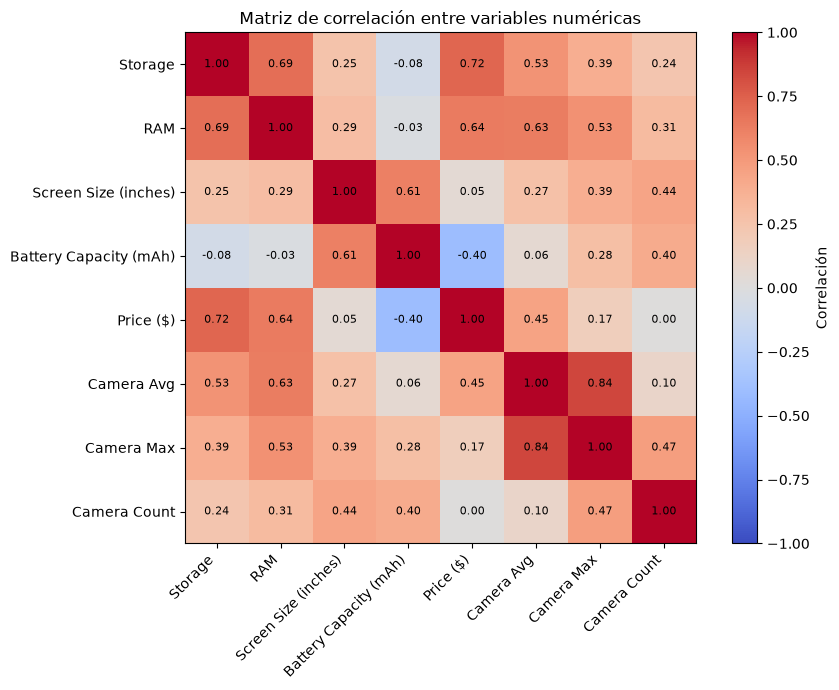

Battery Capacity (mAh)   -0.400135
Camera Count              0.000092
Screen Size (inches)      0.053454
Camera Max                0.166964
Camera Avg                0.445587
RAM                       0.638398
Storage                   0.718983
Name: Price ($), dtype: float64

In [73]:
# 3b. Correlación de variables numéricas con Price:
num_df = mobiles.select_dtypes(include='number')
corr_matrix = num_df.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlación')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha='right')
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Anota el valor de correlación en cada celda:
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)

plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

corr_matrix['Price ($)'].drop('Price ($)').sort_values()

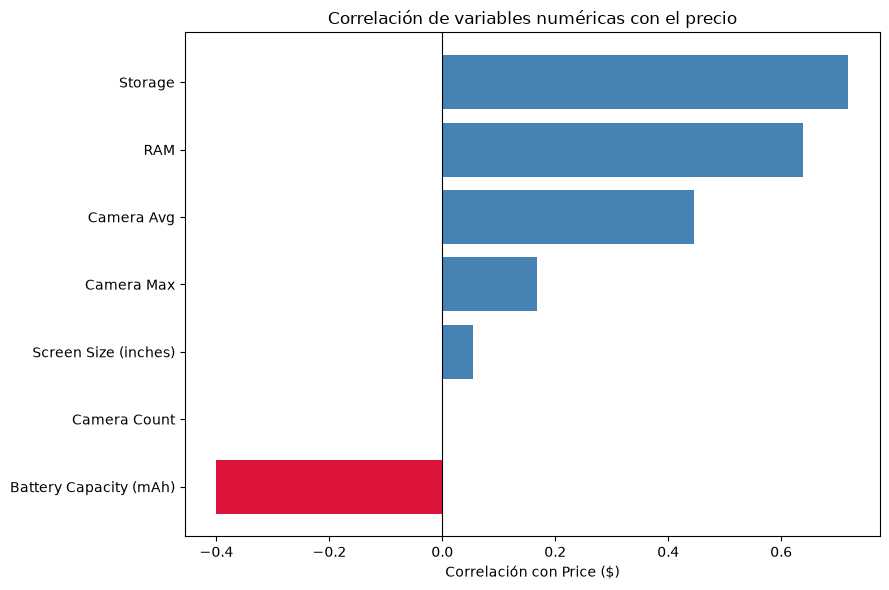

Battery Capacity (mAh)   -0.400135
Camera Count              0.000092
Screen Size (inches)      0.053454
Camera Max                0.166964
Camera Avg                0.445587
RAM                       0.638398
Storage                   0.718983
Name: Price ($), dtype: float64

In [74]:
num_df = mobiles.select_dtypes(include='number')
corr = num_df.corr()['Price ($)'].drop('Price ($)').sort_values()

colors = ['crimson' if v < 0 else 'steelblue' for v in corr.values]

plt.figure(figsize=(9, 6))
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación con Price ($)')
plt.title('Correlación de variables numéricas con el precio')
plt.tight_layout()
plt.show()

corr


In [75]:
mobiles.drop(columns=['Camera Max'], inplace=True)
mobiles.drop(columns=['Camera Count'], inplace=True)

**📝 Interpretación del gráfico de correlaciones:**
*¿Qué variable numérica tiene mayor correlación positiva con el precio? ¿Tiene sentido intuitivo? ¿Tus features derivadas de `Camera (MP)` resultaron útiles o sorpresivamente irrelevantes?*

La variable numérica con mayor relación es storage, seguida de la RAM, estos dos valores son relevantes y tienen un sentido intuitivo, a diferencias de las caracteristicas derivadas de Camera (MP), las cuales realmente si me dejaron sorprendida, puesto que yo pense que la cantidad de camaras podria influir, sin embargo tiene una relacion de 0.0, no aporta realmente. 

La columna de Camera Max pensé que tendria mayor relevancia que Camera Avg, sin embargo es mucho más relevante Camera AVG con una correlación de 0.44, esto demuestra tambien la importancia de hacer distintas fromas de estandarizar los datos. 

Por estas razones se elimina Camera Count y Camera AVG

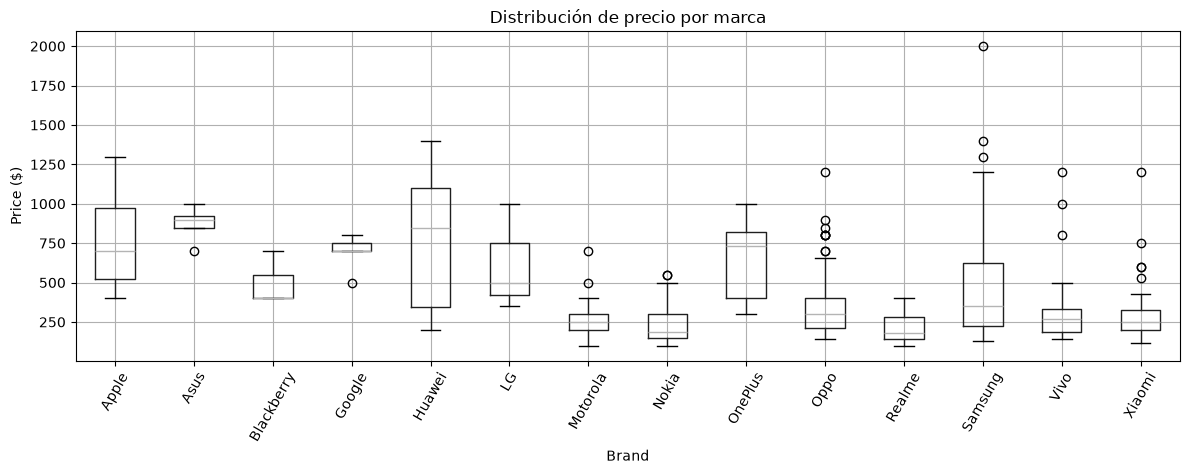

In [76]:
# 3c. Boxplot de Price por Brand:
mobiles.boxplot(column='Price ($)', by='Brand', figsize=(12, 5), rot=60)
plt.title('Distribución de precio por marca')
plt.suptitle('')
plt.xlabel('Brand')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()



**📝 Interpretación del boxplot por Brand:**
*¿Qué marca tiene los precios más elevados en mediana? ¿Cuál tiene mayor dispersión? ¿Hay outliers notables en alguna marca?*

*(Tu respuesta aquí...)*

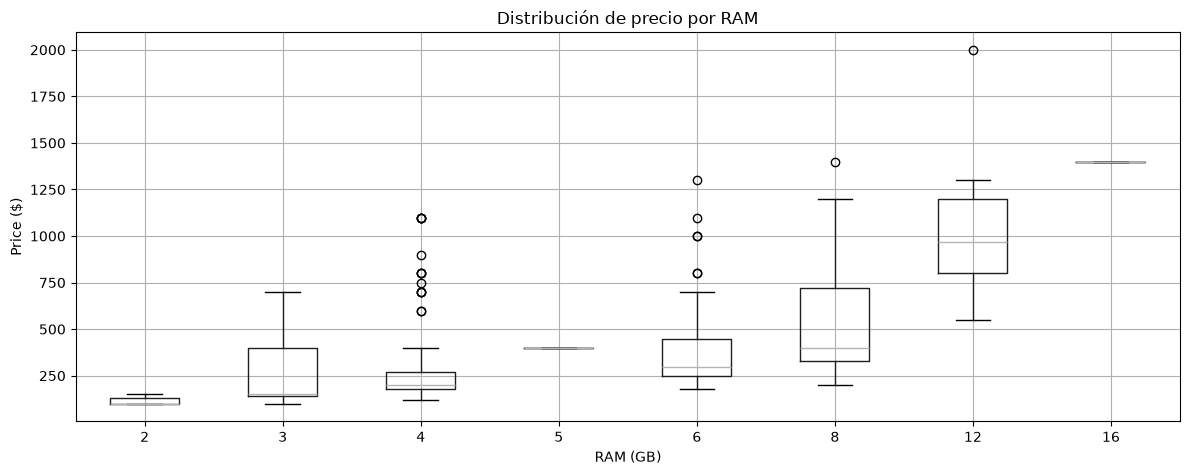

In [77]:
# 3c. Boxplot de Price por RAM (ordena los valores numéricamente antes de graficar):
mobiles.boxplot(column='Price ($)', by='RAM', figsize=(12, 5), rot=0)
plt.title('Distribución de precio por RAM')
plt.suptitle('')
plt.xlabel('RAM (GB)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

**📝 Interpretación del boxplot por RAM:**
*¿A más RAM, mayor precio? ¿La relación es lineal o hay saltos abruptos? ¿Qué implicación tiene esto para el modelo?*

*(Tu respuesta aquí...)*

## 4. División de datos: Train / Validation / Test

Dividirás los datos en **tres conjuntos**:

| Conjunto | Proporción | Uso |
|---|---|---|
| **Train** | 60% | Entrenamiento y GridSearchCV |
| **Validation** | 20% | Comparar modelos y elegir el mejor |
| **Test** | 20% | Evaluación final — ¡solo tocar al final! |

**Pistas:**
- Primero separa la variable objetivo (`Price`) de las features
- Haz un primer `train_test_split` para separar test (20%) del resto (80%)
- Luego haz un segundo `train_test_split` sobre el 80% para obtener train (75% del 80% = 60% total) y validation (25% del 80% = 20% total)
- Usa `random_state=random_state` en ambas divisiones
- Imprime el tamaño de cada conjunto para verificar las proporciones

> 💡 **¿Por qué tres conjuntos?**
> Si usas el test set para elegir entre modelos, contaminas la evaluación final.
> El validation set te permite comparar modelos honestamente sin «quemar» el test set.

In [78]:
# Renombramos para simplificar referencias en el resto del notebook:
mobiles = mobiles.rename(columns={'Price ($)': 'Price'})

# Separa X e y:
TARGET = 'Price'
X = mobiles.drop(columns=TARGET)
y = mobiles[TARGET]

# Primera división: separa el test set (20%):
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

# Segunda división: del 80% restante, separa train (75%) y validation (25% = 20% del total):
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=random_state
)

# Verifica los tamaños:
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")


Train: 243 (60.0%)
Validation: 81 (20.0%)
Test: 81 (20.0%)


## 5. Identificación de columnas por tipo

Identifica qué columnas son numéricas y cuáles son categóricas para aplicar transformaciones distintas.

**Pistas:**
- Usa `X_train.select_dtypes(include='number').columns` para numéricas
- Usa `X_train.select_dtypes(include='object').columns` para categóricas
- Imprime ambas listas para verificar
- Recuerda tu decisión sobre `Model` (sección 2d): si decidiste descartarla, no debería aparecer aquí

> ⚠️ Si tu columna categórica `Brand` (o cualquier otra que conserves) tiene muchos valores únicos, piensa si `OneHotEncoder` sigue siendo una buena idea, igual que reflexionaste con `Model`.

In [79]:
# Identifica las columnas numéricas
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print("Numéricas:", num_cols)

# Identifica las columnas categóricas
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Categóricas:", cat_cols)

# Revisa cuántos valores únicos tiene cada columna categórica
X_train[cat_cols].nunique()

Numéricas: ['Storage', 'RAM', 'Screen Size (inches)', 'Battery Capacity (mAh)', 'Camera Avg']
Categóricas: ['Brand']


/var/folders/qr/vzz8czj126s74q2ptfggdmcc0000gn/T/ipykernel_55500/1548010695.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


Brand    14
dtype: int64

## 6. Preprocesamiento con ColumnTransformer

Construye un `ColumnTransformer` con las transformaciones apropiadas para cada tipo de columna, siguiendo el mismo patrón usado en el notebook de referencia (Penguins RF & GB): un `Pipeline` numérico y un `Pipeline` categórico combinados en un `ColumnTransformer`.

### Pipeline numérico
1. `SimpleImputer(strategy='median')` — imputa nulos con la mediana (por si algún valor no se pudo limpiar/convertir correctamente)
2. `StandardScaler()` — estandariza las variables

### Pipeline categórico
1. `SimpleImputer(strategy='most_frequent')`
2. `OneHotEncoder(handle_unknown='ignore')`

**Pistas:**
- Combina ambos pipelines en un `ColumnTransformer`, igual que en Penguins:
```python
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)
```
- `num_cols` y `cat_cols` son las listas que definiste en la sección anterior

In [80]:
# Crea el pipeline numérico (SimpleImputer -> StandardScaler)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Crea el pipeline categórico (SimpleImputer -> OneHotEncoder)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combina ambos en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)

## 7. Definición de modelos y búsqueda de hiperparámetros

Define los dos pipelines (RF y GB) y la grilla de hiperparámetros para `GridSearchCV`.

**Pistas para los pipelines:**
```python
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=random_state))
])
```

**Pistas para la grilla de hiperparámetros:**
Nota que el prefijo es `regressor__` (no `classifier__` como en el notebook de referencia):
```python
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}
```

**Pistas para GridSearchCV:**
- Usa `cv=3` para validación cruzada de 3 folds
- Usa `scoring='neg_mean_absolute_error'` (negativo porque GridSearchCV maximiza)
- Usa `n_jobs=-1` para paralelizar y acelerar la búsqueda
- Crea un `GridSearchCV` para el RF y otro para el GB

> 💡 **¿Por qué `neg_mean_absolute_error`?**
> `GridSearchCV` siempre **maximiza** el score. Como el MAE es un error que queremos minimizar, se usa el valor negativo: maximizar `-MAE` equivale a minimizar `MAE`.

In [81]:
# Define los regresores
rf_regressor = RandomForestRegressor(random_state=random_state)
gb_regressor = GradientBoostingRegressor(random_state=random_state)

# Define el pipeline para Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_regressor)
])

# Define el pipeline para Gradient Boosting
pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', gb_regressor)
])

# Define la grilla de hiperparámetros
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5, 10, None],
    'regressor__min_samples_leaf': [1, 5, 10]
}

# Define GridSearchCV para Random Forest
rf_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Define GridSearchCV para Gradient Boosting
gb_search = GridSearchCV(
    pipeline_gb,
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

## 8. Entrenamiento

Entrena ambos modelos sobre los datos de entrenamiento. Puede tardar unos minutos.

**Pistas:**
- Usa `rf_search.fit(X_train, y_train)` y `gb_search.fit(X_train, y_train)`
- Después del entrenamiento, muestra los mejores hiperparámetros con `.best_params_`
- Muestra también el mejor score de CV con `.best_score_` (recuerda que va a ser negativo por `neg_mean_absolute_error`)

> ⚠️ Si el entrenamiento tarda demasiado, reduce la grilla a menos combinaciones (por ejemplo, solo 2 valores por hiperparámetro).

In [93]:
# Entrena el Random Forest (GridSearchCV)
rf_search.fit(X_train, y_train)

# Entrena el Gradient Boosting (GridSearchCV)
gb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [3, 5, ...], 'regressor__min_samples_leaf': [1, 5, ...], 'regressor__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable adde

In [ ]:
# Muestra los mejores hiperparámetros encontrados para Random Forest
print("Random Forest:", rf_search.best_params_)
print("Mejor MAE de CV:", -rf_search.best_score_)

# Muestra los mejores hiperparámetros encontrados para Gradient Boosting
print("Gradient Boosting:", gb_search.best_params_)
print("Mejor MAE de CV:", -gb_search.best_score_)

# El best score se devuelve negativo entonces lo invertimos.

Random Forest: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 50}
Mejor MAE de CV: 76.34378330631417
Gradient Boosting: {'regressor__max_depth': 3, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 100}
Mejor MAE de CV: 78.23140532415127


## 9. Evaluación de métricas — R² y MAE

Evalúa ambos modelos en los tres conjuntos de datos y **compara e interpreta** sus resultados. Esta sección es central en el ejercicio: no basta con calcular los números, tienes que explicar qué significan.

**Métricas a calcular para cada modelo y cada conjunto (train, val, test):**
- **MAE** (`mean_absolute_error`) — error promedio absoluto, **en dólares**. Un MAE de 120 significa que, en promedio, la predicción se equivoca por $120.
- **R²** (`r2_score`) — proporción de la varianza del precio que el modelo logra explicar (1.0 = perfecto, 0.0 = igual que predecir siempre la media).
- (Opcional) **RMSE** — penaliza más los errores grandes que el MAE.

**Pistas:**
- Crea una función `evaluar(nombre, modelo, X, y)` que reciba el modelo y los datos y retorne (o imprima) MAE y R² (y RMSE si quieres)
- Llama a la función para (RF en train), (RF en val), (GB en train), (GB en val)
- **Solo al final**, evalúa en test el modelo que mejor haya funcionado en validación
- Organiza los resultados en una tabla con `pd.DataFrame`

**Preguntas que debes responder con tus resultados (no solo reportar los números):**
- Tu modelo obtuvo un MAE de test de $X. Mirando el rango de precios del dataset (mínimo, máximo, mediana calculados en el EDA), ¿ese error te parece grande o pequeño?
- Tu modelo obtuvo un R² de test de Y. ¿Qué porcentaje de la variabilidad del precio logra explicar el modelo? ¿Qué tan cerca está de 1.0?
- ¿El R² y el MAE cuentan la misma historia, o uno es más optimista que el otro? ¿Por qué podrían diferir?

> 💡 **Señales de sobreajuste:**
> Si el R² en train es 0.98 pero en val es 0.65 → el modelo memorizó el train.
> Un buen modelo tiene métricas similares en train, val y test.

In [84]:
# Crea una función que calcule MAE y R² (y opcionalmente RMSE) dado un modelo y un conjunto de datos:
# def evaluar(nombre, modelo, X, y):
#     y_pred = modelo.predict(X)
#     ...



In [85]:
# Evalúa ambos modelos en train y validación:



In [86]:
# Elige el mejor modelo según val, y evalúalo en el test set:
# ⚠️ Solo hacer esto una vez al final — no uses test para tomar decisiones



**📝 Interpretación de MAE y R² (obligatorio):**
*Responde aquí con tus números reales: ¿cuál es el MAE de test en dólares y qué tan grande es comparado con el precio típico de un teléfono en este dataset? ¿Cuál es el R² de test y qué fracción de la variabilidad del precio explica tu modelo? ¿Consideras que el modelo es útil en la práctica?*

*(Tu respuesta aquí...)*

## 10. Visualización de resultados

Genera las siguientes gráficas para el **mejor modelo en el test set**:

**Gráfica 1 — Real vs Predicho:**
- Scatter plot de `y_test` (eje x) vs `y_pred_test` (eje y)
- Agrega la línea diagonal de predicción perfecta en rojo
- Etiqueta los ejes y agrega el R² en el título

**Gráfica 2 — Distribución de residuos:**
- Histograma de `y_test - y_pred_test`
- Línea vertical en 0
- ¿Los residuos son simétricos alrededor de 0? ¿Hay una cola de errores grandes en teléfonos caros?

**Gráfica 3 — Importancia de features:**
- Accede a las importancias con `modelo.best_estimator_.named_steps['regressor'].feature_importances_`
- Muéstralas como barras horizontales ordenadas de mayor a menor
- Para los nombres de features, recuerda que el `ColumnTransformer` reorganizó las columnas

> 💡 **Pista para nombres de features con ColumnTransformer:**
> Usa `preprocessor.get_feature_names_out()` después de hacer `.fit()` para obtener los nombres en el mismo orden que las importancias.

In [87]:
# Gráfica 1: Real vs Predicho en test set:



In [88]:
# Gráfica 2: Distribución de residuos en test set:



In [89]:
# Gráfica 3: Importancia de features del mejor modelo:
# Pista: feature_importances_ está en el paso 'regressor' del pipeline
# best_model.best_estimator_.named_steps['regressor'].feature_importances_



## 11. Reflexión sobre los resultados

Responde estas preguntas aquí (doble clic para editar):

**1. ¿Qué modelo (RF o GB) funcionó mejor en validación? ¿Y en test? ¿Coinciden?**
*(Tu respuesta aquí...)*

---

**2. Mirando la gráfica de importancia de features, ¿qué variable impacta más el precio? ¿Tus features derivadas de `Camera (MP)` quedaron entre las más importantes?**
*(Tu respuesta aquí...)*

---

**3. ¿Hay indicios de sobreajuste? ¿Cómo lo sabes comparando las métricas de train vs val?**
*(Tu respuesta aquí...)*

---

**4. Vuelve a tu estrategia de limpieza de `Camera (MP)` y `Price ($)` (sección 2). ¿Cambiarías algo ahora que ves los resultados? ¿Probaste alguna alternativa?**
*(Tu respuesta aquí...)*

---

**5. ¿Para qué sirve el conjunto de validación si ya usamos validación cruzada (GridSearchCV) dentro del train? ¿Son lo mismo?**
*(Tu respuesta aquí...)*

## 12. 🧪 Prueba con muestra sintética propia

Diseña **al menos 5 teléfonos ficticios** con perfiles muy diferentes y predice su precio.

La clave es razonar **antes de ejecutar** cuánto debería costar cada teléfono según sus especificaciones.

**Perfiles sugeridos:**

| # | Perfil | Características esperadas |
|---|---|---|
| 1 | Gama alta actual | Marca top, mucha RAM/almacenamiento, cámara múltiple de alta resolución |
| 2 | Cámara como diferencial | Muchos lentes / MP alto, gama media en lo demás |
| 3 | Gama baja | Poca RAM/almacenamiento, batería y cámara modestas |
| 4 | Batería extendida | Batería muy grande (mAh), resto gama media |
| 5 | Compacto económico | Pantalla pequeña, especificaciones básicas |

**Pistas importantes:**
- El DataFrame debe tener **exactamente las mismas columnas** que usó tu pipeline entrenado (recuerda si descartaste `Model` u otras columnas)
- Los valores de columnas categóricas (como `Brand`) deben coincidir con los que aparecen en el dataset original (usa `.unique()` para revisar valores válidos)
- Si creaste features derivadas de `Camera (MP)` (número de cámaras, MP total, etc.), debes calcular esos mismos valores para tus teléfonos ficticios, de forma consistente con la función/lógica que definiste en la sección 2b
- `Storage` y `RAM` deben ser numéricos (sin "GB") — ¡ya que limpiaste esas columnas!
- Usa `mejor_modelo.predict(muestra)` para obtener las predicciones

In [90]:
# Revisa los valores válidos de las columnas categóricas para no cometer errores:
# Pista: for col in cat_cols: print(col, X_train[col].unique())



In [91]:
# Diseña tus 5 teléfonos ficticios.
# ANTES de ejecutar, escribe en comentarios cuánto esperas que cueste cada uno:

# Teléfono 1 (perfil: ...): precio esperado ~$___
# Teléfono 2 (perfil: ...): precio esperado ~$___
# Teléfono 3 (perfil: ...): precio esperado ~$___
# Teléfono 4 (perfil: ...): precio esperado ~$___
# Teléfono 5 (perfil: ...): precio esperado ~$___

# Construye tu DataFrame con las mismas columnas (y features derivadas) que usó tu pipeline:
muestra = pd.DataFrame({
    # Completa con las columnas que tu pipeline final espera
})

muestra

""


In [92]:
# Genera las predicciones de precio para tus teléfonos:
# Pista: predicciones = mejor_modelo.predict(muestra)


# Muestra los resultados en una tabla legible:
# Pista: muestra_result = muestra.copy()
#        muestra_result['Precio Predicho ($)'] = predicciones.round(2)



### Reflexión sobre la muestra sintética

Responde aquí (doble clic para editar):

**1. ¿Las predicciones se acercan a lo que esperabas? ¿Cuál te sorprendió más y por qué?**
*(Tu respuesta aquí...)*

---

**2. ¿El modelo diferencia bien entre un teléfono básico y uno de gama alta? ¿La diferencia de precio predicha te parece razonable?**
*(Tu respuesta aquí...)*

---

**3. Prueba cambiar solo la cámara (número de lentes o MP total) manteniendo todo lo demás igual. ¿Cuánto cambia el precio predicho? ¿Tiene sentido con lo que viste en la importancia de features?**
*(Tu respuesta aquí...)*